# This is a code that automatically does everything needed for weekly singup report.
I used gspread&pandas libraries with python. FIrstly, I created Google Cloud project, then enabled Google Sheets API, created Google Service account and used
its JSON key for sharing access with my python-gspread-service.

TODO: cleaning empty rows/duplicated headers, using mapbox


## 1) Firstly, we need to access our data and prepare it for pandas library. We import necessary libraries, authenticate gspread witht he key and tranform our sheet in python object.


In [ ]:
### Start of the app

import gspread
import pandas as pd
from gspread_dataframe import set_with_dataframe
import numpy as np
# 1. Authenticate using JSON key
gc = gspread.service_account(filename="python-project.json")

# 2. Open the Google Sheet
sh = gc.open_by_url("") #this is the url of the table

# 3. Select the specific worksheet (if there are many)
worksheet = sh.worksheet("weekly-sign-up-report")




## 2)  Then we need to clear the first epmty rows. For future imporvements: delete empty rows, not hardcoded first and second rows.

In [2]:
#Clear first rows
worksheet.delete_rows(1, 2)


{'spreadsheetId': '1mEcaA2HZdA-C388OVNY8BceqnGr9zdtKpkeyhneXpgw',
 'replies': [{}]}

## 3a) Transforming object to dict with get_all_records() then transform it to DataFrame
Do some simple observations of the sheet

In [22]:
df = pd.DataFrame(worksheet.get_all_records())
print(df.head())



       Item ID                 Creation log  \
0  11077822596   Kevin Jan 22, 2026 9:49 PM   
1  11077882403  Kevin Jan 22, 2026 10:11 PM   
2  11078053111  Kevin Jan 22, 2026 11:05 PM   
3  11078812645   Kevin Jan 23, 2026 2:49 AM   
4  11083932786   Kevin Jan 23, 2026 1:30 PM   

  What type of placement are you interested in?  \
0                                100% In-Person   
1                Flexible - I can do any format   
2                  Some virtual, some in-person   
3                Flexible - I can do any format   
4                                  100% Virtual   

  Which province do you reside in? What City do you live in?  \
0                          Ontario             Richmond Hill   
1                 British Columbia                 Vancouver   
2                          Ontario             Richmond Hill   
3                          Ontario                 Etobicoke   
4                          Ontario                   Toronto   

  Which organization refe

## 3b) Deleting empty and unnecessary rows, removing duplicate headers

In [6]:
df = df.replace("Non CSC-above 30", np.nan).dropna(how="all")
df = df.replace("", np.nan).dropna(how="all")

# first non empty row = header
header = df.iloc[0]
df = df[df.apply(lambda r: not r.equals(header), axis=1)]
df = df.reset_index(drop=True)
df.index

# remove any row that is identical to the header row
df = df[~df.apply(lambda r: r.tolist() == df.columns.tolist(), axis=1)]
df = df.reset_index(drop=True)


## 3c)  Clean data: resolve the cities. As they are typed by responders, the answers with the same meaning can have different form (like "toronto", "Toronto", "Toronto, On").
We will resolve the most popular cases in a function and normalize our columns.

In [19]:
def clean_city_column(df, column="What City do you live in?"):
    ser = df[column].astype(str).str.strip().str.lower()

    # drop province info if any
    ser = ser.str.split(",").str[0]
    ser = ser.str.split("(").str[0]
    ser = ser.str.replace("-", " ", regex=True)

    ser = ser.str.title()
    df[column] = ser
    return df

## 4) Simple function with geopy for quick matching city-coutry in the future
execution takes around 11 seconds

In [12]:
from geopy.exc import GeocoderTimedOut, GeocoderUnavailable
import time
from geopy.geocoders import Nominatim

geolocator = Nominatim(
    user_agent="my_canada_location_checker_2025",
    timeout=10
)

city_cache = {} # for caching

def detect_country(city_name):
    if not city_name:
        return None

    city_name = city_name.strip().lower()

    if city_name in city_cache:
        return city_cache[city_name]

    try:
        time.sleep(1)
        loc = geolocator.geocode(
            city_name,
            addressdetails=True,
            exactly_one=True,
            language="en"
        )
        country = loc.raw.get("address", {}).get("country") if loc else None
        city_cache[city_name] = country
        return country

    except (GeocoderTimedOut, GeocoderUnavailable):
        return None

print(detect_country("Toronto")) #testing function
print(detect_country("Moscow"))
print(detect_country("Vancouver"))

Canada
Russia
Canada


## 5) Task 3b. Sorting the provinces: if respondee chooses Other province, check the city, if not canadian -> replace field with "Outside Canada", then find the coutry using the function above
Using boolean masks for sorting

In [23]:
provinces = ["Ontario", "British Columbia", "Quebec", "Newfoundland and Labrador", "Prince Edward Island", "Nova Scotia", "Alberta", "New Brunswick", "Manitoba", "Saskatchewan"]

province_col = "Which province do you reside in?"
city_col = "What City do you live in?"

df = clean_city_column(df)
#if province is canadian - coutry is canada
mask_canadian = df[province_col].isin(provinces)
df.loc[mask_canadian, "Country"] = "Canada"

#if other - detect city and check its country
mask_other = df[province_col].isin(["Other", "Other province"])
df.loc[mask_other, "Country"] = df.loc[mask_other, city_col].apply(detect_country)
# among those find rows that are NOT in Canada (just in case someone did mistake and put other province, but lives in Canada).
mask_other_not_canada = mask_other & (df["Country"] != "Canada")
df.loc[mask_other_not_canada, province_col] = "Outside Canada"
df["Country"].head()

0    Canada
1    Canada
2    Canada
3    Canada
4    Canada
Name: Country, dtype: str

## 6) Task 3c. Renaming cloumns

In [24]:
df = df.rename(columns={'What type of placement are you interested in?': 'Placement type', 'Which province do you reside in?': 'Province',
                        "What City do you live in?": "City", "Which organization referred you to this opportunity?": "Referal", "What is your age range?": "Age range"})

### Move column country to column city

In [10]:
cols = list(df.columns)

city_i = cols.index("City")
country_i = cols.index("Country")

# Remove and reinsert to move "Country" after "City"
cols.insert(city_i + 1, cols.pop(country_i))

df = df[cols]


,Item ID,Creation log,Placement type,Province,City,Country,Referal,Age range
0,10610843002,"Jess Scott Nov 21, 2025 2:19 AM",Flexible - I can do any format,British Columbia,Vancouver,Canada,YRES Website/Flyer/Social Media,25 - 30
1,10610848077,"Jess Scott Nov 21, 2025 2:21 AM",Flexible - I can do any format,British Columbia,Burnaby,Canada,YRES Website/Flyer/Social Media,25 - 30
2,10616583469,"Jess Scott Nov 21, 2025 4:51 PM",100% In-Person,Ontario,Markham,Canada,Parents,15 - 19
3,10616977079,"Jess Scott Nov 21, 2025 5:51 PM",100% Virtual,Ontario,Cherry Valley,Canada,Other,25 - 30
4,10617876344,"Jess Scott Nov 22, 2025 1:12 AM","Some virtual, some in-person",Ontario,Brampton,Canada,Volunteer Toronto,25 - 30
5,10619035592,"Jess Scott Nov 22, 2025 12:49 PM","Some virtual, some in-person",Ontario,Toronto,Canada,Volunteer Toronto,12 - 14
6,10619418813,"Jess Scott Nov 22, 2025 5:18 PM","Some virtual, some in-person",Ontario,Toronto,Canada,Volunteer Toronto,15 - 19
7,10620290288,"Jess Scott Nov 23, 2025 4:01 AM",100% Virtual,Ontario,Mississauga,Canada,Other,25 - 30
8,10621420167,"Jess Scott Nov 23, 2025 1:23 PM",100% Virtual,British Columbia,Vancouver,Canada,Other,25 - 30
9,10621424130,"Jess Scott Nov 23, 2025 1:23 PM",Flexible - I can do any format,Ontario,North York,Canada,Volunteer Toronto,25 - 30


## Final: posting changes to the existing sheet.

In [25]:
set_with_dataframe(
    worksheet,
    df,
    row=1,         # start at row 1 (A1)
    col=1,         # column A
    include_index=False,
    include_column_header=True
)

# Task 5. Viz report/visualizations.

In [26]:
import matplotlib.pyplot as plt
df = pd.DataFrame(worksheet.get_all_records())
print(df.head())


       Item ID                 Creation log                  Placement type  \
0  11077822596   Kevin Jan 22, 2026 9:49 PM                  100% In-Person   
1  11077882403  Kevin Jan 22, 2026 10:11 PM  Flexible - I can do any format   
2  11078053111  Kevin Jan 22, 2026 11:05 PM    Some virtual, some in-person   
3  11078812645   Kevin Jan 23, 2026 2:49 AM  Flexible - I can do any format   
4  11083932786   Kevin Jan 23, 2026 1:30 PM                    100% Virtual   

           Province           City Country                          Referal  \
0           Ontario  Richmond Hill  Canada                  School Guidance   
1  British Columbia      Vancouver  Canada  YRES Website/Flyer/Social Media   
2           Ontario  Richmond Hill  Canada  YRES Website/Flyer/Social Media   
3           Ontario      Etobicoke  Canada    Volunteer Connect York Region   
4           Ontario        Toronto  Canada  YRES Website/Flyer/Social Media   

  Age range  
0   15 - 19  
1   20 - 24  
2   15 -

### We will import geopandas and use shapefiles of countries/provinces to plot some of graphs
If the signups are only from one country - Canada - we will do it with shapefiles, if there are more then one country in df - we use bar plot

In [28]:
# Geopandas
import geopandas as gpd

world = gpd.read_file("data/ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp")
canada = world[world["ADMIN"] == "Canada"]
provs = gpd.read_file("data/ne_10m_admin_1_states_provinces/ne_10m_admin_1_states_provinces.shp")
type(canada)


geopandas.geodataframe.GeoDataFrame

In [30]:
unique_countries = df["Country"].dropna().unique()
# Condition for graphs: if Canada is the only country of signups, we show the map, in other cases - bar plot.
country_counts = df['Country'].value_counts()
country_df = country_counts.reset_index()
country_df.columns = ["Country", "Sign-ups"]
only_canada = (len(unique_countries) == 1 and unique_countries[0] == "Canada")
df.shape

(78, 8)

### Plotting the signups by country

/tmp/ipykernel_1169282/702393885.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = seaborn.barplot(


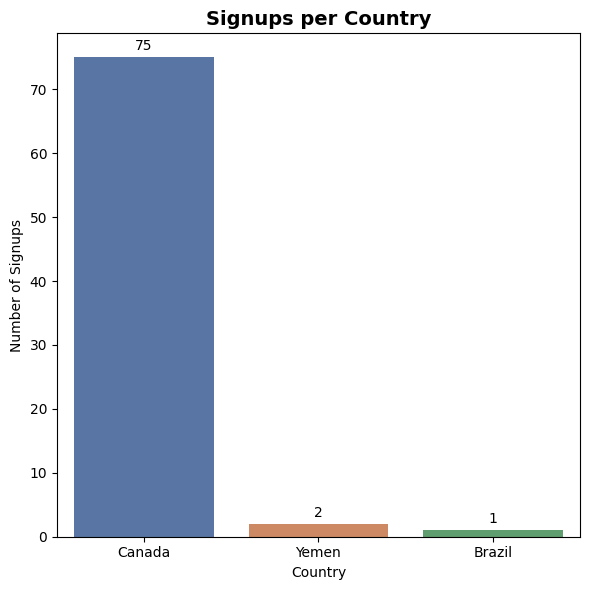

In [33]:

import seaborn

if only_canada:
    total_signups = df.shape[0] #number of rows = total signups
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.set_title("Signups by Country", fontsize=14)
    colors = plt.cm.Pastel1(np.linspace(0, 1, len(total_signups.values)))
    '''
    Map shapes are stored in CRS. We transform Canada GeoDataFrame to projected CRS with epsg=3857 - common “Web Mercator” projection used by many maps
    Then compute centroid from canada's geometry attribute and reproject it to our CRS world matching the coordinates
    After we take the first geometry - centroid - and get its coordinates
    '''
    cx, cy = canada.to_crs(epsg=3857).geometry.centroid.to_crs(world.crs).iloc[0].coords[0] #(-97.25572657833406, 67.70129023948249)


    ax.text(-115, 60, str(total_signups), ha="left", va="top", fontsize=20, weight="bold")
    canada.plot(ax=ax, color="blue", edgecolor="white", colors=colors)
    ax.set_axis_off()
else:
    plt.figure(figsize = (6, 6))
    ax = seaborn.barplot(
        data=country_df,
        x="Country",
        y="Sign-ups",
        palette="deep"
    )

    ax.set_title("Signups per Country", fontsize=14, weight="bold")
    ax.set_xlabel("Country")
    ax.set_ylabel("Number of Signups")

    # Add values on top of bars
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", padding=3)

    plt.tight_layout()
    plt.show()

### Plotting the signups by province
We'll do both bar and map chart. I cannot decide which looks better.

In [34]:
province_counts = df['Province'].value_counts()
province_counts #counting each country

Province
Ontario             70
British Columbia     4
Outside Canada       3
Other province       1
Name: count, dtype: int64

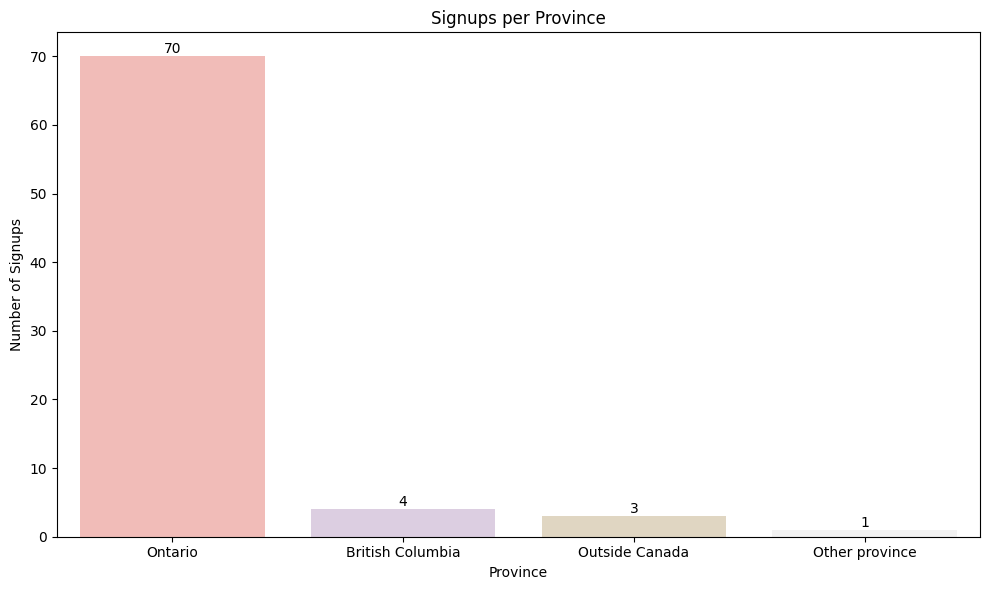

In [40]:
x = province_counts.index
y = province_counts.values

palette = plt.cm.Pastel1(np.linspace(0, 1, len(x))).tolist()

plt.figure(figsize=(10, 6))
ax = seaborn.barplot(
    x=x,
    y=y,
    hue=x,         
    palette=palette,
    legend=False
)

ax.set_title("Signups per Province")
ax.set_xlabel("Province")
ax.set_ylabel("Number of Signups")

for bar in ax.patches:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{int(h)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


In [41]:
can_provs = provs[provs["adm0_a3"] == "CAN"]   # “adm0_a3” = country code
merged = can_provs.merge(province_counts, left_on="name", right_on="Province", how="left")
merged["count"] = merged["count"].fillna(0)


Text(0.5, 1.0, 'Nov 28 - Dec 4, 2025 By province')

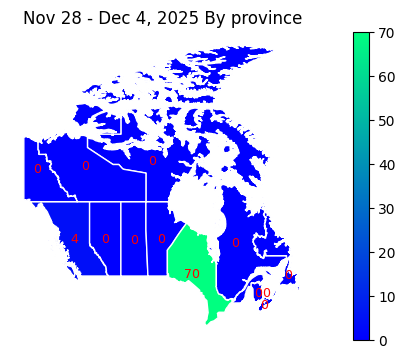

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
merged.plot(
    ax=ax,
    column="count",
    cmap="winter",
    edgecolor="white",
    legend=True,
)

for _, row in merged.iterrows():
    x, y = row.geometry.representative_point().coords[0]
    ax.text(x, y, int(row["count"]), ha="center", va="center", fontsize=9, color="red")

ax.set_axis_off()
ax.set_title("Nov 28 - Dec 4, 2025 By province")


### Plotting the signups by the city

In [48]:
city_counts = df["City"].value_counts()
df.loc[df["City"].str.lower() == "canada", "City"] = ""
city_counts

City
Toronto                   23
Markham                   12
Richmond Hill              5
Scarborough                4
North York                 3
Vaughan                    3
Etobicoke                  2
Waterloo                   2
Ajax                       2
Brampton                   2
Mississauga                2
Sanaa                      2
Vancouver                  1
Gatineau                   1
Victoria                   1
Sudbury                    1
Whitchurch Stouffville     1
Bolton                     1
Hamilton                   1
Surrey                     1
Thunder Bay                1
King City                  1
London                     1
Kamloops                   1
Mississsauga               1
York                       1
Whitby                     1
Recife                     1
Name: count, dtype: int64

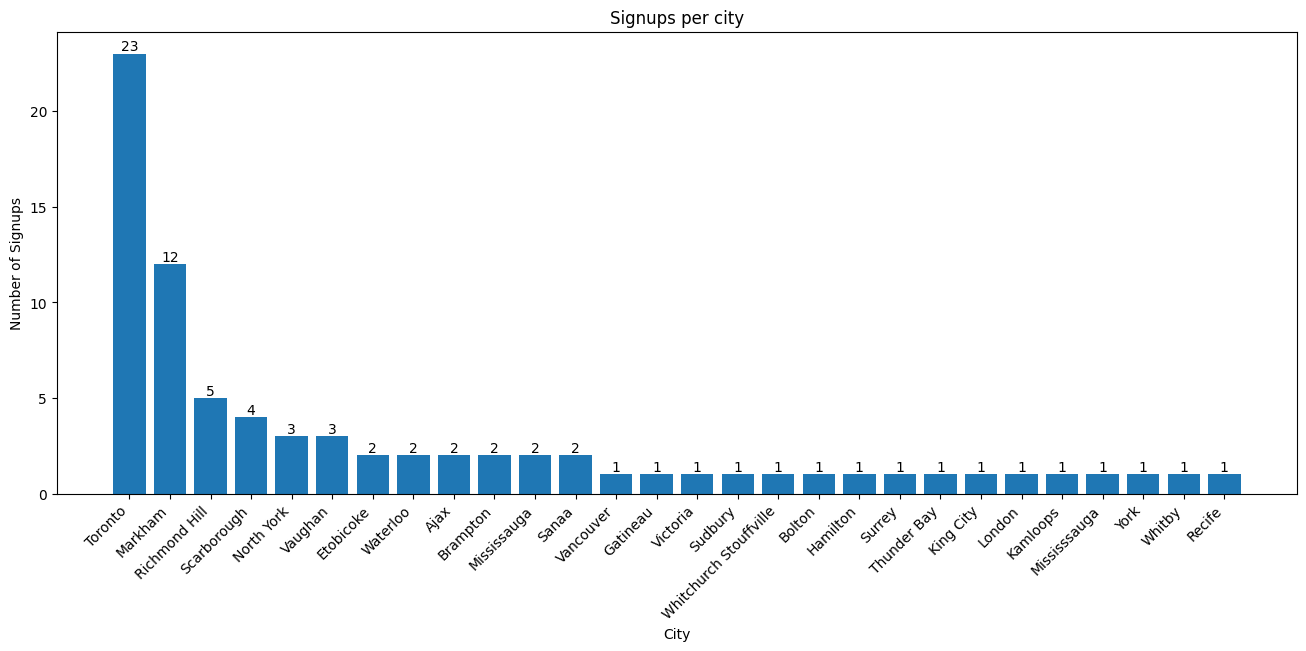

In [50]:
plt.figure(figsize = (16, 6))
bars = plt.bar(city_counts.index, city_counts.values)
plt.title("Signups per city")
plt.xlabel("City")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Signups")
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # center of bar
        height,                             # top of bar
        str(int(height)),                   # label text
        ha="center",
        va="bottom"
    )

plt.show()

### Plotting the signups by the day

In [54]:
# 1) Convert column Creation log to datetime for future visualizations
df["datetime_str"] = df["Creation log"].str.extract(r'([A-Z][a-z]{2}\s+\d{1,2},\s+\d{4}\s+\d{1,2}:\d{2}\s+[AP]M)') #like Sep 26, 2025 3:07 AM
df["timestamp"] = pd.to_datetime(df["datetime_str"])
df["timestamp"] #like 2025-09-26 03:07:00

#2) Extracting weekday and indexing, so that Sunday is 0
df["weekday"] = df["timestamp"].dt.day_name()
# remap: Sunday first
order_map = {
    "Sunday": 0, "Monday": 1, "Tuesday": 2, "Wednesday": 3,
    "Thursday": 4, "Friday": 5, "Saturday": 6
}
df["weekday_order"] = df["weekday"].map(order_map)
df["weekday_order"]

#3) count signups per day
weekday_counts = df.groupby("weekday_order")["timestamp"].count()
weekday_counts.index = weekday_counts.index.map({v: k for k, v in order_map.items()}) #convert numeric keys back to names
weekday_counts

/tmp/ipykernel_1169282/3524194395.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["timestamp"] = pd.to_datetime(df["datetime_str"])


weekday_order
Sunday       10
Monday       11
Tuesday      13
Wednesday    12
Thursday     15
Friday       13
Saturday      4
Name: timestamp, dtype: int64

In [55]:
# counts provinces per day
weekday_province_counts = df.groupby(["weekday", "Province"]).size().unstack(fill_value=0)
weekday_province_counts

Province,British Columbia,Ontario,Other province,Outside Canada
weekday,,,,
Friday,2,10,1,0
Monday,1,9,0,1
Saturday,0,3,0,1
Sunday,0,10,0,0
Thursday,1,14,0,0
Tuesday,0,13,0,0
Wednesday,0,11,0,1


In [56]:
all_provinces = sorted(
set(weekday_province_counts.columns)
)
all_provinces
palette = plt.cm.Pastel1(np.linspace(0, 1, len(all_provinces)))
prov_to_color = dict(zip(all_provinces, palette))
prov_to_color

{'British Columbia': array([0.98431373, 0.70588235, 0.68235294, 1.        ]),
 'Ontario': array([0.87058824, 0.79607843, 0.89411765, 1.        ]),
 'Other province': array([0.89803922, 0.84705882, 0.74117647, 1.        ]),
 'Outside Canada': array([0.94901961, 0.94901961, 0.94901961, 1.        ])}

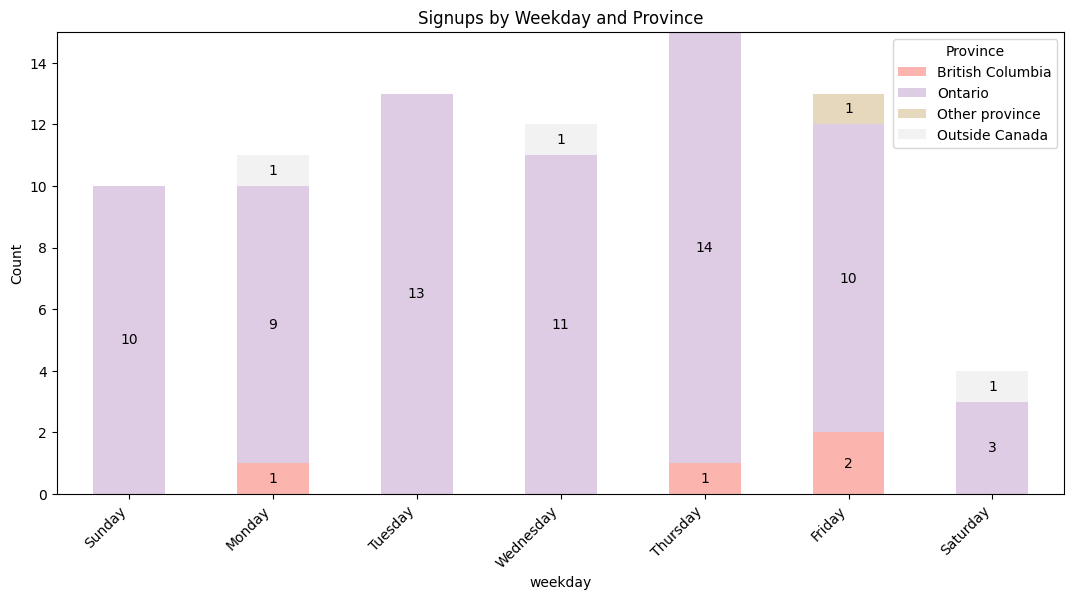

In [57]:
#4) Visualization
ax = weekday_province_counts.loc[
    ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
].plot(kind="bar", stacked=True, figsize=(13, 6), color=[prov_to_color[p] for p in weekday_province_counts.columns])

plt.title("Signups by Weekday and Province")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Province")
for container in ax.containers:
    labels = [
        f"{int(v)}" if v != 0 else ""
        for v in container.datavalues
    ]
    ax.bar_label(container, labels=labels, label_type="center")


### Plotting the signups by the time of the day



In [58]:

df["time_hours"] = df["timestamp"].dt.hour
hours_count = df["time_hours"].value_counts().sort_index()
hour_province_counts = (
    df.groupby(["time_hours", "Province"])
      .size()
      .unstack(fill_value=0)          # columns = provinces, rows = hours
      .sort_index()                   # ensure hours go 0 → 23
)

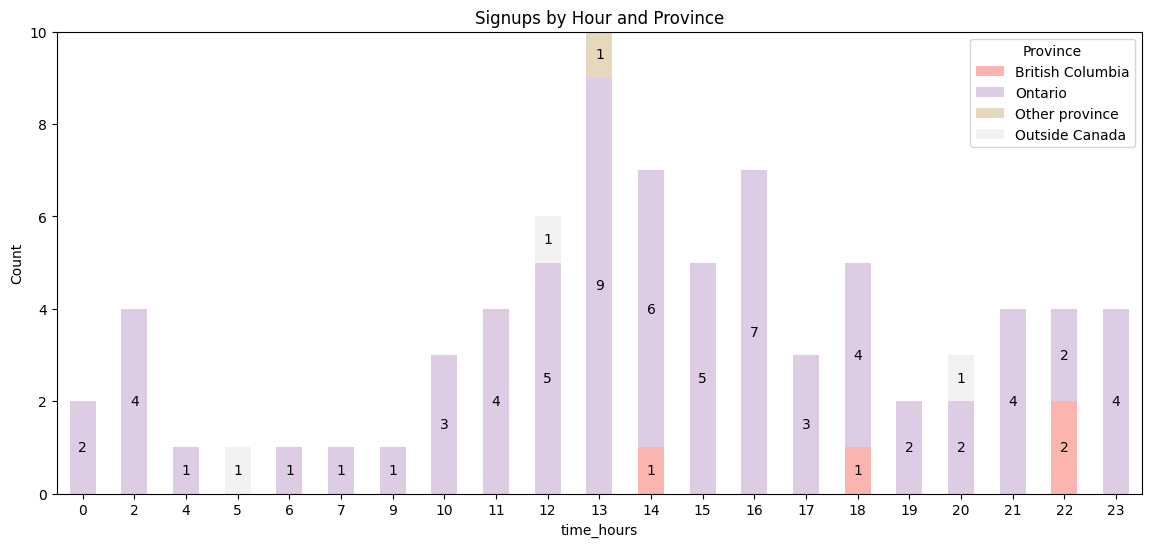

In [59]:
ax = hour_province_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6),
    color=[prov_to_color[p] for p in hour_province_counts.columns],
)

plt.title("Signups by Hour and Province")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Province")
for container in ax.containers:
    labels = [
        f"{int(v)}" if v != 0 else ""
        for v in container.datavalues
    ]
    ax.bar_label(container, labels=labels, label_type="center")

### Plotting the signups by placement type

In [66]:
placement_province_counts = (
    df.groupby(["Placement type", "Province"])
      .size()
      .unstack(fill_value=0)          # columns = provinces, rows = hours
      .sort_index()                   # ensure hours go 0 → 23
)
placement_province_counts

Province,British Columbia,Ontario,Other province,Outside Canada
Placement type,,,,
100% In-Person,0,19,0,2
100% Virtual,2,20,0,1
Flexible - I can do any format,1,18,0,0
"Some virtual, some in-person",1,13,1,0


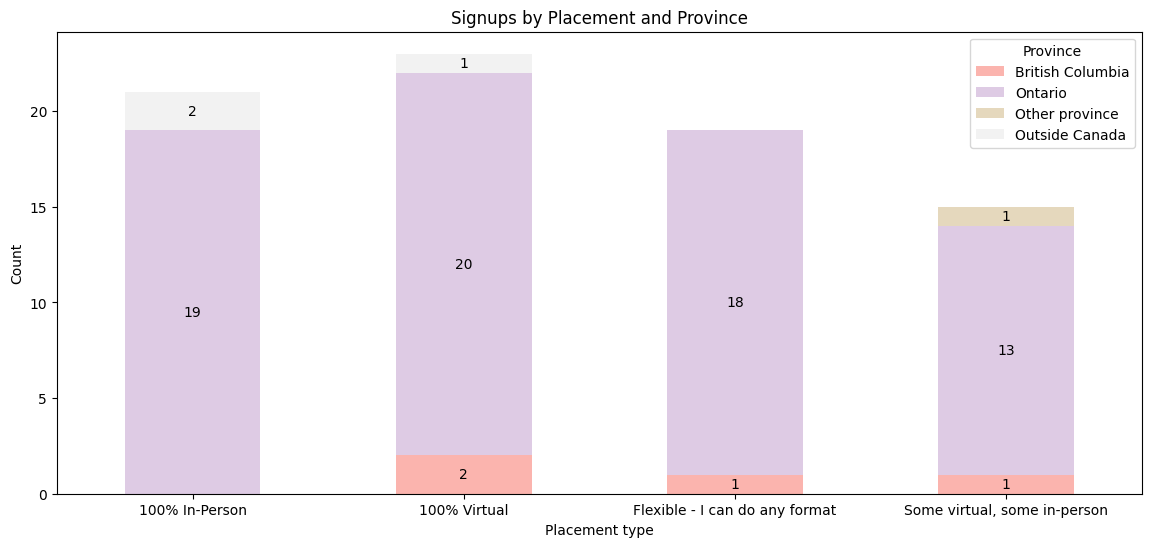

In [64]:

ax = placement_province_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6),
    color = [prov_to_color[p] for p in placement_province_counts.columns]
)

plt.title("Signups by Placement and Province")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Province")
for container in ax.containers:
    labels = [
        f"{int(v)}" if v != 0 else ""
        for v in container.datavalues
    ]
    ax.bar_label(container, labels=labels, label_type="center")

### Plotting the signups by age range

In [70]:
# age_count = df["Age range"].value_counts().sort_index()
# age_count
age_province_count =(
    df.groupby(["Age range", "Province"])
    .size()
    .unstack(fill_value=0) .sort_index()
)
age_province_count

Province,British Columbia,Ontario,Other province,Outside Canada
Age range,,,,
12 - 14,0,8,0,0
15 - 19,0,24,1,0
20 - 24,2,20,0,0
25 - 30,1,10,0,0
31-54,1,7,0,3
55+,0,1,0,0


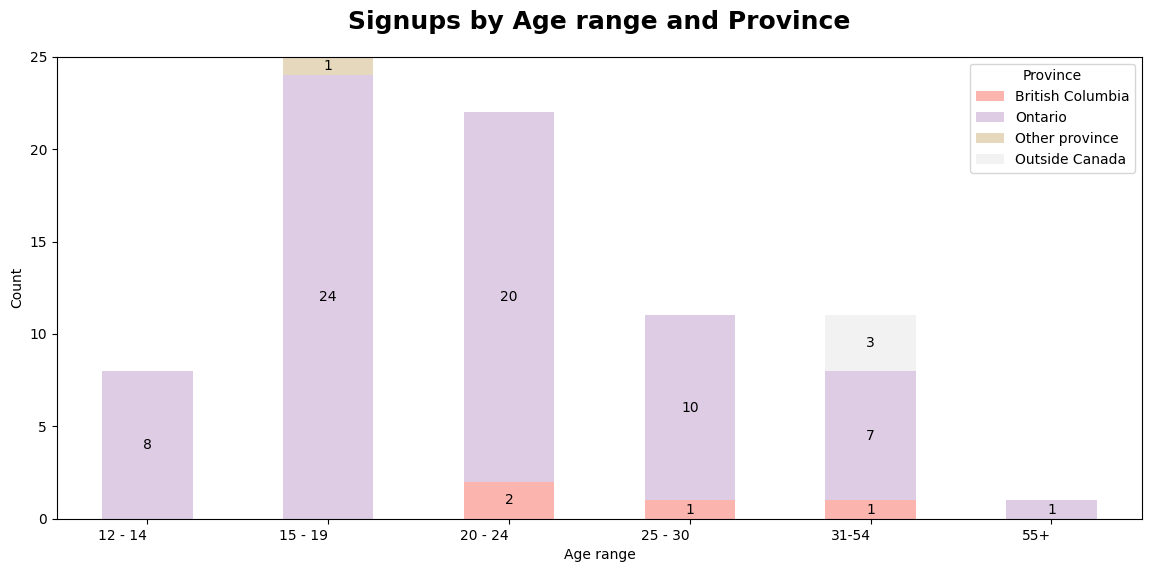

In [71]:
ax = age_province_count.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6),
     color=[prov_to_color[p] for p in age_province_count.columns],
)
plt.title("Signups by Age range and Province",fontsize=18, pad=20, weight="bold")
plt.ylabel("Count")
plt.xticks(rotation=0, ha="right")
plt.legend(title="Province")
for container in ax.containers:
    labels = [
        f"{int(v)}" if v != 0 else ""
        for v in container.datavalues
    ]
    ax.bar_label(container, labels=labels, label_type="center")

## Count by referrals

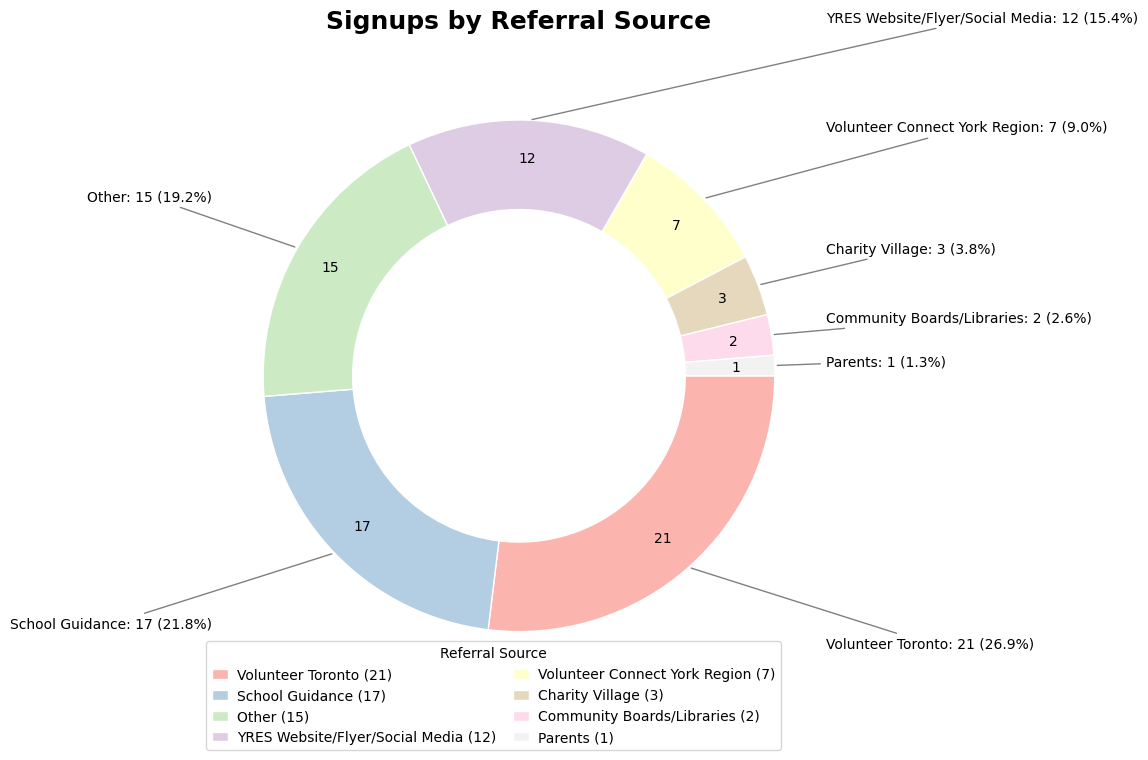

In [ ]:
# Data
ref_counts = df["Referal"].value_counts()
labels = ref_counts.index
values = ref_counts.values
total = values.sum()

colors = plt.cm.Pastel1(np.linspace(0, 1, len(values)))

fig, ax = plt.subplots(figsize=(10, 8))

# --- Donut chart ---
wedges, texts, autotexts = ax.pie(
    values,
    labels=None,
    autopct=lambda pct: f"{int(round(pct*total/100))}",
    pctdistance=0.85,
    startangle=0,
    counterclock=False,
    colors=colors,
    wedgeprops=dict(width=0.35, edgecolor="white")
)

# title
ax.set_title("Signups by Referral Source", fontsize=18, pad=20, weight="bold")

# labels outside
kw = dict(arrowprops=dict(arrowstyle="-", color="gray", lw=1),
          va="center")

for i, w in enumerate(wedges):
    ang = (w.theta2 - w.theta1)/2. + w.theta1
    y = np.sin(np.deg2rad(ang))
    x = np.cos(np.deg2rad(ang))
    ax.annotate(
        f"{labels[i]}: {values[i]} ({values[i]/total:.1%})",
        xy=(x, y),
        xytext=(1.2*np.sign(x), 1.4*y),
        horizontalalignment="left" if x > 0 else "right",
        **kw
    )

# --- Equal aspect makes it a perfect circle ---
ax.set_aspect("equal")

# --- Legend ---
ax.legend(
    wedges,
    [f"{l} ({v})" for l, v in zip(labels, values)],
    title="Referral Source",
    loc="center left",
     bbox_to_anchor=(0, 0),
    ncol=2,
    columnspacing=1.2,
    handlelength=1.2,
    handletextpad=0.6,
)
plt.tight_layout()
plt.show()


## Done by Mariia Shmidt (https://github.com/markshmidt)
## PLEASE DON'T USE THE CODE WITHOUT GIVING CREDIT. THANK YOU.